In [1]:
# To do
# Select percent of train dataset
# Balance it
# Re-run model with evaluation to see if pred_labels match earlier labels

# Intro:  Using Pseudo-labeling with Emotions Classifier

In this notebook, I will take the dataset that I already ran through the "j-hartmann/emotion-english-roberta-large" model so that it now has emotion labels.  I will balance the data so the neutral class is not so dominant.  Then I will split it into train/test/validate, and run it through the model again.  This way I can see if the model is consistent in its classification.

In [2]:
pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 76.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [4]:
from datasets import Dataset

In [5]:
pip install accelerate

Note: you may need to restart the kernel to use updated packages.


In [6]:
import torch
if torch.cuda.is_available():
    device_name = torch.device("cuda")
else:
    device_name = torch.device('cpu')
print("Using {}.".format(device_name))

Using cpu.


In [7]:

import accelerate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments


In [8]:
from datasets import load_dataset
import pandas as pd



In [9]:
pip install jsonlines

Note: you may need to restart the kernel to use updated packages.


In [10]:

import jsonlines

data = []

with jsonlines.open('/content/drive/MyDrive/DATA/data/transcripts_en_2023-01-16.json', 'r') as reader:
    for line in reader:
        data.append(line)

# Now you have the data as a list of dictionaries
# You can perform further processing or save it to a file if needed

# Example: Print the content of each JSON object
for item in data:
    print(item)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/DATA/data/transcripts_en_2023-01-16.json'

In [ ]:


# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(data)

In [ ]:
df.head()

,date,persons,transcript_unfiltered,kremlin_id,place,title,teaser,tags,transcript_filtered,wordlist
0,1999-12-31T00:01:00,[],"Vladimir Putin: Dear friends, On New Year’s Ev...",22280,"The Kremlin, Moscow",New Year Address by Acting President Vladimir ...,,[],"Dear friends, On New Year’s Eve, my family and...","[dear, friend, ,, on, New, Year, ’s, Eve, ,, m..."
1,1999-12-31T00:02:00,[],"Vladimir Putin: Good afternoon, distinguished ...",22326,"The Kremlin, Moscow",Address at an expanded meeting of the Russian ...,,[],"Good afternoon, distinguished colleagues. This...","[good, afternoon, ,, distinguished, colleague,..."
2,1999-12-31T00:03:00,[],"Boris Yeltsin: Dear Russians, In a few hours w...",24080,"The Kremlin, Moscow",Statement by Boris Yeltsin,,[],,[]
3,2000-01-04T00:00:00,[],"Question: Mr Putin, the sudden resignation of ...",24377,Moscow,Interview with the ORT TV Channel,,[],Let’s try. It was about ten days before the Ne...,"[let, ’s, try, ., , it, be, about, ten, day, ..."
4,2000-01-11T00:00:00,[],"Vladimir Putin: Dear friends, We are again gat...",24116,"State Kremlin Palace, Moscow",Speech at gala function marking the second mil...,,[],"Dear friends, We are again gathered here today...","[dear, friend, ,, we, be, again, gather, here,..."


In [ ]:
# Segment Dataframe (keeping only date, title, and unfiltered_transcript)
# Maximum sequence length for your model
max_seq_length = 512

# Define a function to segment the text and retain metadata
def segment_text(row):
    date = row['date']
    title = row['title']
    transcript = row['transcript_unfiltered']

    # Segment the transcript into chunks
    text_chunks = [transcript[i:i+max_seq_length] for i in range(0, len(transcript), max_seq_length)]

    # Create a list of dictionaries to preserve metadata for each chunk
    segmented_data = [{'Date': date, 'Title': title, 'Segmented_Transcript': chunk} for chunk in text_chunks]

    return segmented_data

# Apply the segmentation function to the entire DataFrame
segmented_data = df.apply(segment_text, axis=1)

# Create a new DataFrame from the segmented data
segmented_df = pd.DataFrame([item for sublist in segmented_data for item in sublist])

# Display the segmented DataFrame
print(segmented_df)


                       Date  \
0       1999-12-31T00:01:00   
1       1999-12-31T00:01:00   
2       1999-12-31T00:01:00   
3       1999-12-31T00:01:00   
4       1999-12-31T00:02:00   
...                     ...   
157032  2023-01-13T14:35:00   
157033  2023-01-13T14:35:00   
157034  2023-01-13T14:35:00   
157035  2023-01-13T14:35:00   
157036  2023-01-13T14:35:00   

                                                    Title  \
0       New Year Address by Acting President Vladimir ...   
1       New Year Address by Acting President Vladimir ...   
2       New Year Address by Acting President Vladimir ...   
3       New Year Address by Acting President Vladimir ...   
4       Address at an expanded meeting of the Russian ...   
...                                                   ...   
157032                     Comment for Rossiya TV channel   
157033                     Comment for Rossiya TV channel   
157034                     Comment for Rossiya TV channel   
157035           

In [ ]:
segmented_df.to_csv('/content/drive/MyDrive/DATA 495/segmented_transcripts.csv')

In [ ]:
# save smaller section of segmented_df to csv
segmented_df_short = segmented_df.iloc[0:100]

In [ ]:
segmented_df_short.head()

,Date,Title,Segmented_Transcript
0,1999-12-31T00:01:00,New Year Address by Acting President Vladimir ...,"Vladimir Putin: Dear friends, On New Year’s Ev..."
1,1999-12-31T00:01:00,New Year Address by Acting President Vladimir ...,a minute. I promise you that any attempts to a...
2,1999-12-31T00:01:00,New Year Address by Acting President Vladimir ...,"own, the president acted in full compliance wi..."
3,1999-12-31T00:01:00,New Year Address by Acting President Vladimir ...,kindest and the most loved holiday in Russia....
4,1999-12-31T00:02:00,Address at an expanded meeting of the Russian ...,"Vladimir Putin: Good afternoon, distinguished ..."


In [ ]:
segmented_df_short.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  100 non-null    object
 1   Title                 100 non-null    object
 2   Segmented_Transcript  100 non-null    object
dtypes: object(3)
memory usage: 2.5+ KB


In [ ]:
# create year column
segmented_df_short['Date'] = pd.to_datetime(segmented_df_short['Date'])

<ipython-input-17-19dc53ccd092>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmented_df_short['Date'] = pd.to_datetime(segmented_df_short['Date'])


In [ ]:
segmented_df_short['Year'] = segmented_df_short['Date'].dt.year

<ipython-input-18-dc9f1ab1e8a3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmented_df_short['Year'] = segmented_df_short['Date'].dt.year


In [ ]:
# save segmented_df_short as csv
segmented_df_short.to_csv('/content/drive/MyDrive/DATA 495/segmented_short.csv', index=False)

In [ ]:
# load as a hugging face dataset
segmented_short = load_dataset("csv", data_files="/content/drive/MyDrive/DATA 495/segmented_short.csv")

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
segmented_short

DatasetDict({
    train: Dataset({
        features: ['Date', 'Title', 'Segmented_Transcript', 'Year'],
        num_rows: 100
    })
})

In [ ]:
# Define the split ratios (e.g., 80% for training, 20% for testing)
train_ratio = 0.8
test_ratio = 1 - train_ratio

# Split the data into training and test sets
train_dataset = segmented_short['train'].train_test_split(test_size=test_ratio)
test_dataset = train_dataset['test']
train_dataset = train_dataset['train']

In [ ]:
# Load model directly


tokenizer = AutoTokenizer.from_pretrained("j-hartmann/emotion-english-roberta-large")
model = AutoModelForSequenceClassification.from_pretrained("j-hartmann/emotion-english-roberta-large")

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

In [ ]:
# set the model to run on the GPU

model.to(device_name)


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
 

In [ ]:
# Define a function to tokenize a specific column
def tokenize_column(batch):
    return tokenizer(batch['Segmented_Transcript'], padding=True, truncation=True)



In [ ]:
# Tokenize the specific column
tokenized_short = segmented_short.map(tokenize_column, batched=True)

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:


# load tokenizer and model, create trainer
model_name = "j-hartmann/emotion-english-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.to(device_name)
trainer = Trainer(model=model)

In [ ]:
# Assuming you have a dataset containing only a 'train' split
train_dataset = tokenized_short['train']
# Run predictions on the 'train' split
predictions = trainer.predict(train_dataset)



In [ ]:
import numpy as np

In [ ]:
# Transform predictions to labels
preds = predictions.predictions.argmax(-1)
labels = pd.Series(preds).map(model.config.id2label)
scores = (np.exp(predictions[0])/np.exp(predictions[0]).sum(-1,keepdims=True)).max(1)

In [ ]:
# scores raw
temp = (np.exp(predictions[0])/np.exp(predictions[0]).sum(-1,keepdims=True))

In [ ]:
# pred_texts as column name containing the text samples in the dataset
pred_texts = train_dataset['Title']  # You can use 'test' or 'validation' instead of 'train' if needed


In [ ]:
# work in progress
# container
anger = []
disgust = []
fear = []
joy = []
neutral = []
sadness = []
surprise = []

# extract scores (as many entries as exist in pred_texts)
for i in range(len(pred_texts)):
  anger.append(temp[i][0])
  disgust.append(temp[i][1])
  fear.append(temp[i][2])
  joy.append(temp[i][3])
  neutral.append(temp[i][4])
  sadness.append(temp[i][5])
  surprise.append(temp[i][6])

In [ ]:
# Create DataFrame with texts, predictions, labels, and scores
df = pd.DataFrame(list(zip(pred_texts, preds,labels,scores,  anger, disgust, fear, joy, neutral, sadness, surprise)), columns=['text','pred','label','score', 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'])
df.head()

,text,pred,label,score,anger,disgust,fear,joy,neutral,sadness,surprise
0,New Year Address by Acting President Vladimir ...,5,sadness,0.620263,0.086754,0.025621,0.088218,0.051659,0.099013,0.620263,0.028473
1,New Year Address by Acting President Vladimir ...,4,neutral,0.387280,0.381828,0.050218,0.136920,0.017879,0.387280,0.019315,0.006560
2,New Year Address by Acting President Vladimir ...,3,joy,0.879539,0.008654,0.007884,0.002745,0.879539,0.081518,0.014070,0.005590
3,New Year Address by Acting President Vladimir ...,3,joy,0.950798,0.001942,0.001510,0.000501,0.950798,0.019587,0.003814,0.021847
4,Address at an expanded meeting of the Russian ...,4,neutral,0.745792,0.057704,0.033110,0.019957,0.118155,0.745792,0.020820,0.004461


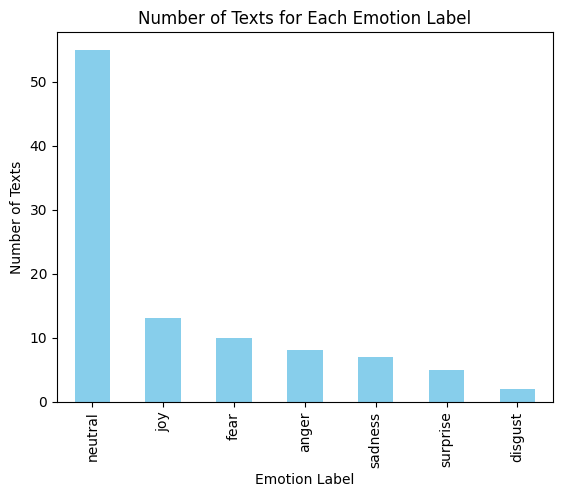

In [ ]:
import matplotlib.pyplot as plt




# Group by 'label' and count the number of texts for each label
label_counts = df['label'].value_counts()

# Plotting
label_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Emotion Label')
plt.ylabel('Number of Texts')
plt.title('Number of Texts for Each Emotion Label')
plt.show()


# Work on Normal Dataset

In [ ]:
segmented_transcripts = load_dataset("csv", data_files="/content/drive/MyDrive/DATA 495/segmented_transcripts.csv")

Extracting data files:   0%|          | 0/1 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
segmented_transcripts

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'Date', 'Title', 'Segmented_Transcript'],
        num_rows: 157037
    })
})

In [ ]:
segmented_transcripts.set_format(type="pandas")

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(segmented_transcripts["train"][:])

In [ ]:
df = segmented_transcripts["train"][:]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157037 entries, 0 to 157036
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   Unnamed: 0            157037 non-null  int64 
 1   Date                  157037 non-null  object
 2   Title                 157037 non-null  object
 3   Segmented_Transcript  157037 non-null  object
dtypes: int64(1), object(3)
memory usage: 4.8+ MB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157037 entries, 0 to 157036
Data columns (total 4 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Unnamed: 0            157037 non-null  int64         
 1   Date                  157037 non-null  datetime64[ns]
 2   Title                 157037 non-null  object        
 3   Segmented_Transcript  157037 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 4.8+ MB


In [ ]:
# Extract the year from the 'Date' column and store it in a new column
df['Year'] = df['Date'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157037 entries, 0 to 157036
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Unnamed: 0            157037 non-null  int64         
 1   Date                  157037 non-null  datetime64[ns]
 2   Title                 157037 non-null  object        
 3   Segmented_Transcript  157037 non-null  object        
 4   Year                  157037 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 6.0+ MB


In [ ]:
segmented_transcripts.reset_format()

In [ ]:
import matplotlib.pyplot as plt

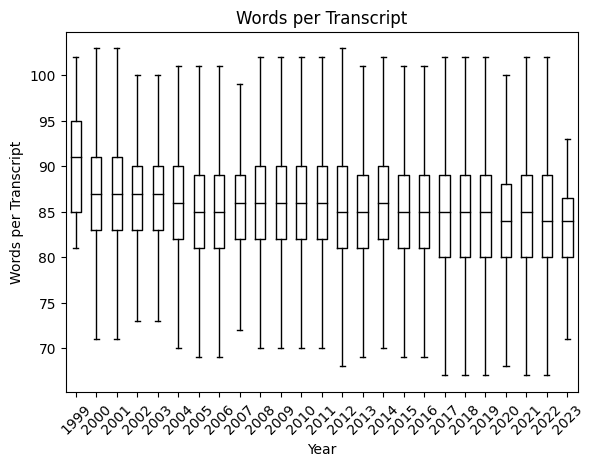

In [ ]:
# Calculate the words per transcript
df["Words per Transcript"] = df["Segmented_Transcript"].str.split().apply(len)

# Create a box plot grouped by year
df.boxplot("Words per Transcript", by="Year", grid=False, showfliers=False, color='black')

# Customize the plot labels
plt.suptitle("")
plt.xlabel("Year")
plt.ylabel("Words per Transcript")

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45)

# Show the plot
plt.show()

In [ ]:
# Define the split ratios (e.g., 80% for training, 20% for testing)
train_ratio = 0.8
test_ratio = 1 - train_ratio

# Split the data into training and test sets
train_dataset = segmented_transcripts['train'].train_test_split(test_size=test_ratio)
test_dataset = train_dataset['test']
train_dataset = train_dataset['train']

In [ ]:
# Load model directly


tokenizer = AutoTokenizer.from_pretrained("j-hartmann/emotion-english-roberta-large")
model = AutoModelForSequenceClassification.from_pretrained("j-hartmann/emotion-english-roberta-large")

In [ ]:
# Define a function to tokenize a specific column
def tokenize_column(batch):
    return tokenizer(batch['Segmented_Transcript'], padding=True, truncation=True)



In [ ]:
# Tokenize the specific column
tokenized_data = segmented_transcripts.map(tokenize_column, batched=True)

Map:   0%|          | 0/157037 [00:00<?, ? examples/s]

In [ ]:


# load tokenizer and model, create trainer
model_name = "j-hartmann/emotion-english-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

trainer = Trainer(model=model)

#### Full dataset


In [ ]:

train_dataset = tokenized_data['train']

# Run predictions on the 'train' split
predictions = trainer.predict(train_dataset)



In [ ]:
# Extract the predicted labels from the predictions
predicted_labels = [int(prediction.argmax()) for prediction in predictions.predictions]

# Add the predicted labels as a new column to the dataset
labeled_dataset = train_dataset.add_column('predicted_sentiment', predicted_labels)


In [ ]:
labeled_dataset

Dataset({
    features: ['Unnamed: 0', 'Date', 'Title', 'Segmented_Transcript', 'input_ids', 'attention_mask', 'predicted_sentiment'],
    num_rows: 157037
})

In [ ]:
# Save the updated dataset
labeled_dataset.save_to_disk("/content/drive/MyDrive/DATA 495/labeled_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/157037 [00:00<?, ? examples/s]

In [ ]:
# pred_texts as column name containing the text samples in the dataset
pred_texts = train_dataset['Title']


In [ ]:
# Transform predictions to labels
preds = predictions.predictions.argmax(-1)
labels = pd.Series(preds).map(model.config.id2label)
scores = (np.exp(predictions[0])/np.exp(predictions[0]).sum(-1,keepdims=True)).max(1)

In [ ]:
# scores raw
temp = (np.exp(predictions[0])/np.exp(predictions[0]).sum(-1,keepdims=True))

In [ ]:
# work in progress
# container
anger = []
disgust = []
fear = []
joy = []
neutral = []
sadness = []
surprise = []

# extract scores (as many entries as exist in pred_texts)
for i in range(len(pred_texts)):
  anger.append(temp[i][0])
  disgust.append(temp[i][1])
  fear.append(temp[i][2])
  joy.append(temp[i][3])
  neutral.append(temp[i][4])
  sadness.append(temp[i][5])
  surprise.append(temp[i][6])

In [ ]:
# Create DataFrame with texts, predictions, labels, and scores
df = pd.DataFrame(list(zip(pred_texts,preds,labels,scores,  anger, disgust, fear, joy, neutral, sadness, surprise)), columns=['text','pred','label','score', 'anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'])
df.head()

,text,pred,label,score,anger,disgust,fear,joy,neutral,sadness,surprise
0,New Year Address by Acting President Vladimir ...,5,sadness,0.620263,0.086754,0.025621,0.088218,0.051659,0.099013,0.620263,0.028473
1,New Year Address by Acting President Vladimir ...,4,neutral,0.387280,0.381828,0.050218,0.136920,0.017879,0.387280,0.019315,0.006560
2,New Year Address by Acting President Vladimir ...,3,joy,0.879539,0.008654,0.007884,0.002745,0.879539,0.081518,0.014070,0.005590
3,New Year Address by Acting President Vladimir ...,3,joy,0.950798,0.001942,0.001510,0.000501,0.950798,0.019587,0.003814,0.021847
4,Address at an expanded meeting of the Russian ...,4,neutral,0.745792,0.057704,0.033110,0.019957,0.118155,0.745792,0.020820,0.004461


In [ ]:
# save results to csv

df.to_csv("/content/drive/MyDrive/DATA 495/modeled_data_emotion-english-roberta-large.csv")

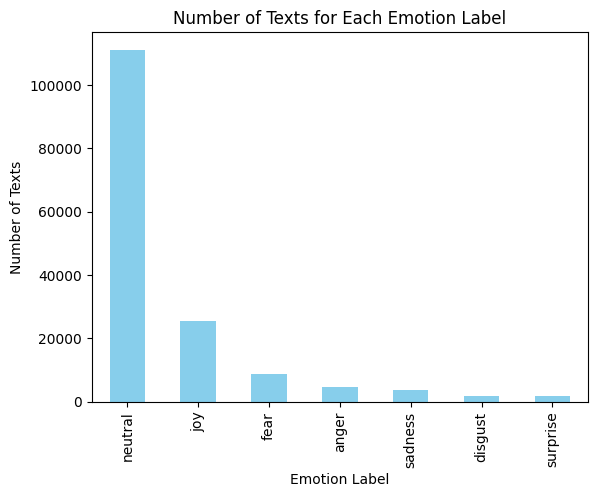

In [ ]:

# Group by 'label' and count the number of texts for each label
label_counts = df['label'].value_counts()

# Plotting
label_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Emotion Label')
plt.ylabel('Number of Texts')
plt.title('Number of Texts for Each Emotion Label')
plt.show()


In [ ]:
# convert original dataset to pandas dataframe full_data


In [ ]:
# add new df as columns to full_data

In [ ]:
# undersample the dataframe so it is more balanced

In [ ]:
# convert undersampled dataframe to Hugging Face Dataset

In [ ]:
# save Dataset to disk as "undersampled_emotion_dataset"

In [ ]:
# convert full_data back to Hugging Face Dataset

In [ ]:
# Save Dataset to disk as "labeled_emotion_dataset"

## Explore Results of Model


In [ ]:
# filter dataframe by label
df_anger = df[df['label'] == 'anger']
df_disgust = df[df['label'] == 'disgust']
df_fear = df[df['label'] == 'fear']
df_joy = df[df['label'] == 'joy']
df_surprise = df[df['label'] == 'surprise']
df_sadness = df[df['label'] == 'sadness']
df_neutral = df[df['label'] == 'neutral']

In [ ]:
df_anger.head()

,text,pred,label,score,anger,disgust,fear,joy,neutral,sadness,surprise
14,Statement by Boris Yeltsin,0,anger,0.398847,0.398847,0.159085,0.055656,0.009082,0.173385,0.195499,0.008446
16,Statement by Boris Yeltsin,0,anger,0.510987,0.510987,0.066615,0.127887,0.054197,0.207351,0.027218,0.005744
26,Interview with the ORT TV Channel,0,anger,0.775123,0.775123,0.082116,0.012975,0.003660,0.077754,0.035319,0.013054
58,Interview with ORT Channel,0,anger,0.415674,0.415674,0.024362,0.399258,0.003521,0.097066,0.029281,0.030837
66,Interview with ORT Channel,0,anger,0.466329,0.466329,0.239500,0.174180,0.001819,0.099570,0.012269,0.006335


## Dealing with the Unbalanced Data:  Undersampling the Neutral Class

In [ ]:
import random

In [ ]:
# Specify the class to undersample (e.g., 'neutral')
class_to_undersample = 4



In [ ]:


# Specify the class to count (e.g., 'neutral')
class_to_count = 4

# Count the occurrences of the 'neutral' class in the 'emotion_labels' column
num_neutral_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'neutral' samples: {num_neutral_samples}")

Number of 'neutral' samples: 111117


In [ ]:
# Specify the class to count (e.g., 'neutral')
class_to_count = 3

# Count the occurrences of the 'joy' class in the 'predicted_sentiment' column
num_joy_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'joy' samples: {num_joy_samples}")

Number of 'joy' samples: 25528


In [ ]:
# Specify the class to count (e.g., 'neutral')
class_to_count = 0

# Count the occurrences of the 'anger' class in the 'predicted_sentiment' column
num_anger_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'anger' samples: {num_anger_samples}")

Number of 'anger' samples: 4468


In [ ]:
# Specify the class to count (e.g., 'neutral')
class_to_count = 6

# Count the occurrences of the 'joy' class in the 'predicted_sentiment' column
num_surprise_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'surprise' samples: {num_surprise_samples}")

Number of 'surprise' samples: 1714


In [ ]:
# Specify the class to count (e.g., 'neutral')
class_to_count = 1

# Count the occurrences of the 'joy' class in the 'predicted_sentiment' column
num_disgust_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'disgust' samples: {num_disgust_samples}")

Number of 'disgust' samples: 1808


In [ ]:
# Specify the class to count (e.g., 'neutral')
class_to_count = 2

# Count the occurrences of the 'joy' class in the 'predicted_sentiment' column
num_fear_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'fear' samples: {num_fear_samples}")

Number of 'fear' samples: 8716


In [ ]:
# Specify the class to count (e.g., 'neutral')
class_to_count = 5

# Count the occurrences of the 'joy' class in the 'predicted_sentiment' column
num_sadness_samples = sum(1 for label in labeled_dataset['predicted_sentiment'] if label == class_to_count)

print(f"Number of 'sadness' samples: {num_sadness_samples}")

Number of 'sadness' samples: 3686


In [ ]:
# Specify the minimum number of samples to keep for each class
min_samples_to_keep = 1714

In [ ]:
min_class_size = min(num_anger_samples, num_disgust_samples, num_fear_samples, num_joy_samples, num_neutral_samples, num_sadness_samples, num_surprise_samples)

In [ ]:
# Proportional undersampling
#undersampled_indices = []
#for label in set(labeled_dataset['predicted_sentiment']):
 #   class_indices = [i for i, l in enumerate(labeled_dataset['predicted_sentiment']) if l == label]
 #   num_samples_to_keep_class = min(min_samples_to_keep, min_class_size)
 #   undersampled_indices += random.sample(class_indices, num_samples_to_keep_class)

In [ ]:
# Find indices of samples from other classes
#non_undersampled_indices = [i for i in range(len(labeled_dataset)) if i not in undersampled_indices]


In [ ]:
# Combine indices to create the final undersampled dataset
#undersampled_dataset = labeled_dataset.select(undersampled_indices + non_undersampled_indices)


In [ ]:
# Save the undersampled dataset
#undersampled_dataset.save_to_disk("/content/drive/MyDrive/DATA 495/undersampled_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/157037 [00:00<?, ? examples/s]

In [ ]:
#undersampled_dataset

Dataset({
    features: ['Unnamed: 0', 'Date', 'Title', 'Segmented_Transcript', 'input_ids', 'attention_mask', 'predicted_sentiment'],
    num_rows: 157037
})

In [ ]:
import torch
from torch.utils.data import DataLoader
from datasets import load_from_disk

batch_size = 32

# Load your labeled dataset from disk without specifying a split name
labeled_dataset = load_from_disk('/content/drive/MyDrive/DATA 495/undersampled_dataset')

# Specify the maximum sequence length
max_seq_length = 512  # Adjust as needed

# Extract relevant features from the dataset
input_ids = [torch.tensor(sample['input_ids']) for sample in labeled_dataset]
attention_mask = [torch.tensor(sample['attention_mask']) for sample in labeled_dataset]
predicted_sentiment = [sample['predicted_sentiment'] for sample in labeled_dataset]

# Pad or truncate sequences to the specified length
input_ids_padded = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
attention_mask_padded = torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0)  # Assuming your attention_mask values are 0 or 1

# Create a DataLoader with the padded sequences
collated_dataset = torch.utils.data.TensorDataset(input_ids_padded, attention_mask_padded)
collated_dataloader = DataLoader(collated_dataset, batch_size=batch_size, shuffle=False)

# Run predictions on the collated dataset
predictions_2 = trainer.predict(collated_dataloader.dataset)

# Extract the new predicted sentiments from the model output
new_predicted_sentiments = predictions_2.predictions.argmax(dim=1).tolist()

# Compare the existing predicted sentiments with the new ones
for existing, new in zip(predicted_sentiment, new_predicted_sentiments):
    print(f"Existing: {existing}, New: {new}")



TypeError: ignored

Note:  Use the newly